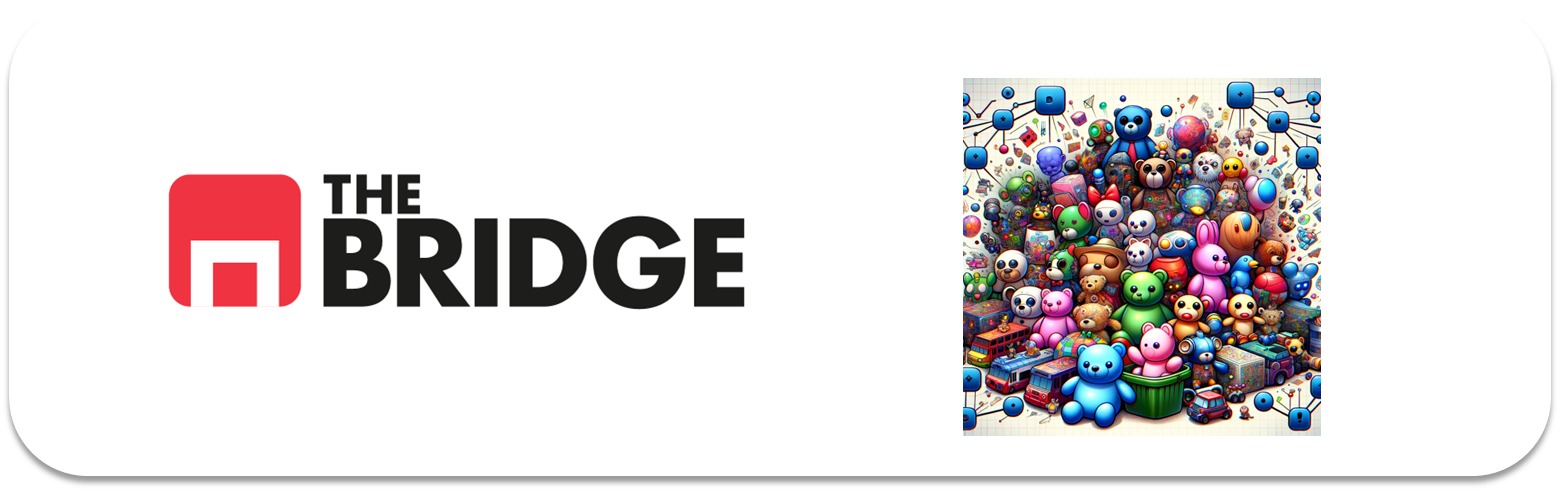

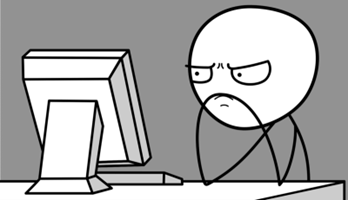

Para ejercitarte y afianzar lo aprendido sobre **Clustering Jerárquico**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Descripción del "Problema"

Existen disponibles datos de encuestas y cuestionarios a 26 instituciones. Estas instituciones han sido evaluadas bajo distintos criterios de desempeño, como profesorado, costos, ubicación, becas e infraestructura. Cada criterio va del 1 al 5, siendo 5 el mayor.

El objetivo principal será segmentar las instituciones en grupos basásndonos en los criterios antes mencionados, y luego generar descripciones y recomendaciones a seguir con respecto a cada uno de los grupos identificados. Las recomendaciones pueden ser para distintos clientes.
    </div>

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Ejercicio 1

Carga los datos ("Engg_College_Data") y haz una primera inspección "rápida".

In [2]:
path_to_file = './data/Engg_College_Data.csv'
college_data = pd.read_csv(path_to_file)
college_data.head()

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
0,1,A,5,2,5,5,3
1,2,B,4,2,5,5,3
2,3,C,4,5,5,4,5
3,4,D,5,4,5,4,4
4,5,E,2,5,2,2,5


In [3]:
college_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SR_NO           26 non-null     int64 
 1   Engg_College    26 non-null     object
 2   Teaching        26 non-null     int64 
 3   Fees            26 non-null     int64 
 4   Placements      26 non-null     int64 
 5   Internship      26 non-null     int64 
 6   Infrastructure  26 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.6+ KB


Engg_College --> Abreviatura de Escuela de Ingeniería.  
Teaching --> Docencia.  
Fees --> matrícula (honorarios).  
Placements --> (o work placement). En el ámbito académico, especialmente en el contexto universitario y anglosajón, es un periodo de tiempo en el que un estudiante trabaja temporalmente en una empresa u organización como parte integrada de su programa de estudios.    
Intesrnship --> (pasantía o práctica profesional) en el ámbito académico es una experiencia de aprendizaje experiencial que integra los conocimientos teóricos adquiridos en el aula con su aplicación práctica en un entorno profesional real. Se trata de una forma de educación supervisada, a menudo obligatoria para obtener un título, donde el estudiante trabaja temporalmente en una empresa u organización para desarrollar habilidades, explorar trayectorias profesionales y construir redes de contacto.  

### Ejercicio 2

Crea un train_set con una única variable de tipo índice (que nos servirá para identificar a las instituciones en cada clúster)

In [4]:
train_set = pd.DataFrame(index=college_data["SR_NO"])

In [5]:
train_set

""
SR_NO
1
2
3
4
5
6
7
8
9


In [6]:
train_set.columns

RangeIndex(start=0, stop=0, step=1)

### Ejercicio 3

Determina el tipo de cada variable, haciendo un univariante de las mismas.

In [7]:
def describe_df(df):
    data_dict = {}
    for columna in df.columns:
        data_type = "categorica" if df[columna].dtype == "object" else "numerica"
        valores_nulos = round(df[columna].isna().sum() / len(df) * 100, 1)
        valores_unicos = df[columna].nunique()
        cardinalidad_ptg = round(valores_unicos / len(df) * 100, 2)
        data_dict[columna] = {
            "data_type": data_type,
            "valores_nulos": valores_nulos,
            "valores_unicos": valores_unicos,
            "cardinalidad_ptg": cardinalidad_ptg
        }
    return pd.DataFrame(data_dict).T

In [8]:
describe_df(college_data)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
SR_NO,numerica,0.0,26,100.0
Engg_College,categorica,0.0,26,100.0
Teaching,numerica,0.0,5,19.23
Fees,numerica,0.0,5,19.23
Placements,numerica,0.0,5,19.23
Internship,numerica,0.0,5,19.23
Infrastructure,numerica,0.0,5,19.23


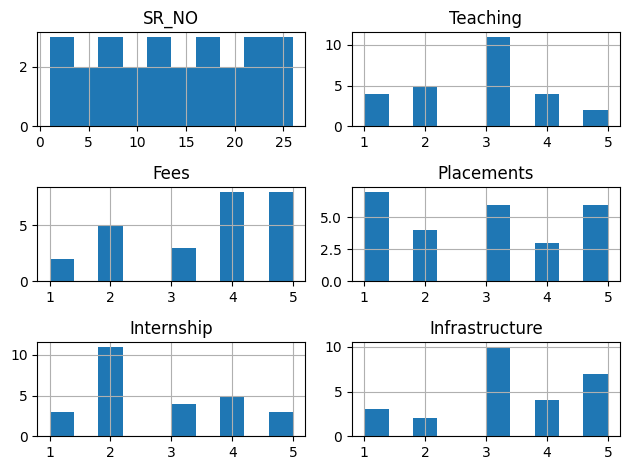

In [ ]:
# Análisis univariante de features numéricas:
college_data.hist()
plt.tight_layout();

In [12]:
print(college_data.describe())

           SR_NO   Teaching       Fees  Placements  Internship  Infrastructure
count  26.000000  26.000000  26.000000   26.000000   26.000000       26.000000
mean   13.500000   2.807692   3.576923    2.884615    2.769231        3.384615
std     7.648529   1.132051   1.331858    1.531716    1.242826        1.298520
min     1.000000   1.000000   1.000000    1.000000    1.000000        1.000000
25%     7.250000   2.000000   2.250000    1.250000    2.000000        3.000000
50%    13.500000   3.000000   4.000000    3.000000    2.000000        3.000000
75%    19.750000   3.000000   5.000000    4.000000    4.000000        4.750000
max    26.000000   5.000000   5.000000    5.000000    5.000000        5.000000


#### Comentarios:  
Convertir 'SR_NO' en el índice (si es necesario) para igualarlo a train_set.   
Todas las variables numéricas están en un rango entre 1 y 5, tienen la misma escala.

Text(0.5, 1.0, 'Variable categórica')

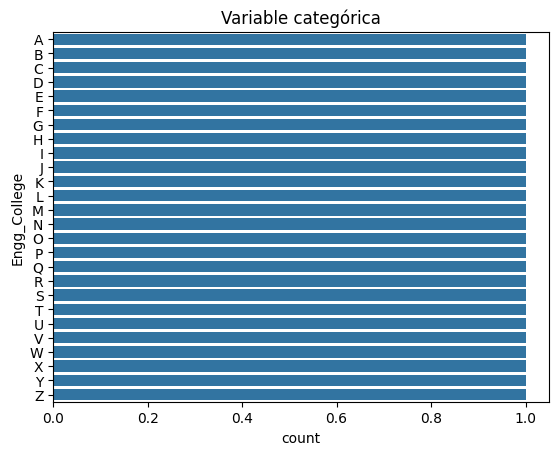

In [ ]:
# Análisis univariante de features categóricas:
sns.countplot(college_data["Engg_College"]).set_title("Variable categórica");

#### Cometarios  
Tal y como se ve en la tabla describe, la variable categórica 'Engg_College' tiene una cardinalidad del 100%, por lo tanto no aporta nada al problema. La quitamos de la lista de features a usar para entrenar el modelo.

In [14]:
college_data.columns

Index(['SR_NO', 'Engg_College', 'Teaching', 'Fees', 'Placements', 'Internship',
       'Infrastructure'],
      dtype='object')

In [15]:
# Selleción de features:
features= ['Teaching', 'Fees', 'Placements', 'Internship',
       'Infrastructure']

### Ejercicio 4

Es hora de hacer el miniEDA. Fíjate que en este caso no tenemos contínuas numéricas que nos permitan ver claramente una clusterización con scatter plots. Compruébalo haciendo un pairplot del dataset.

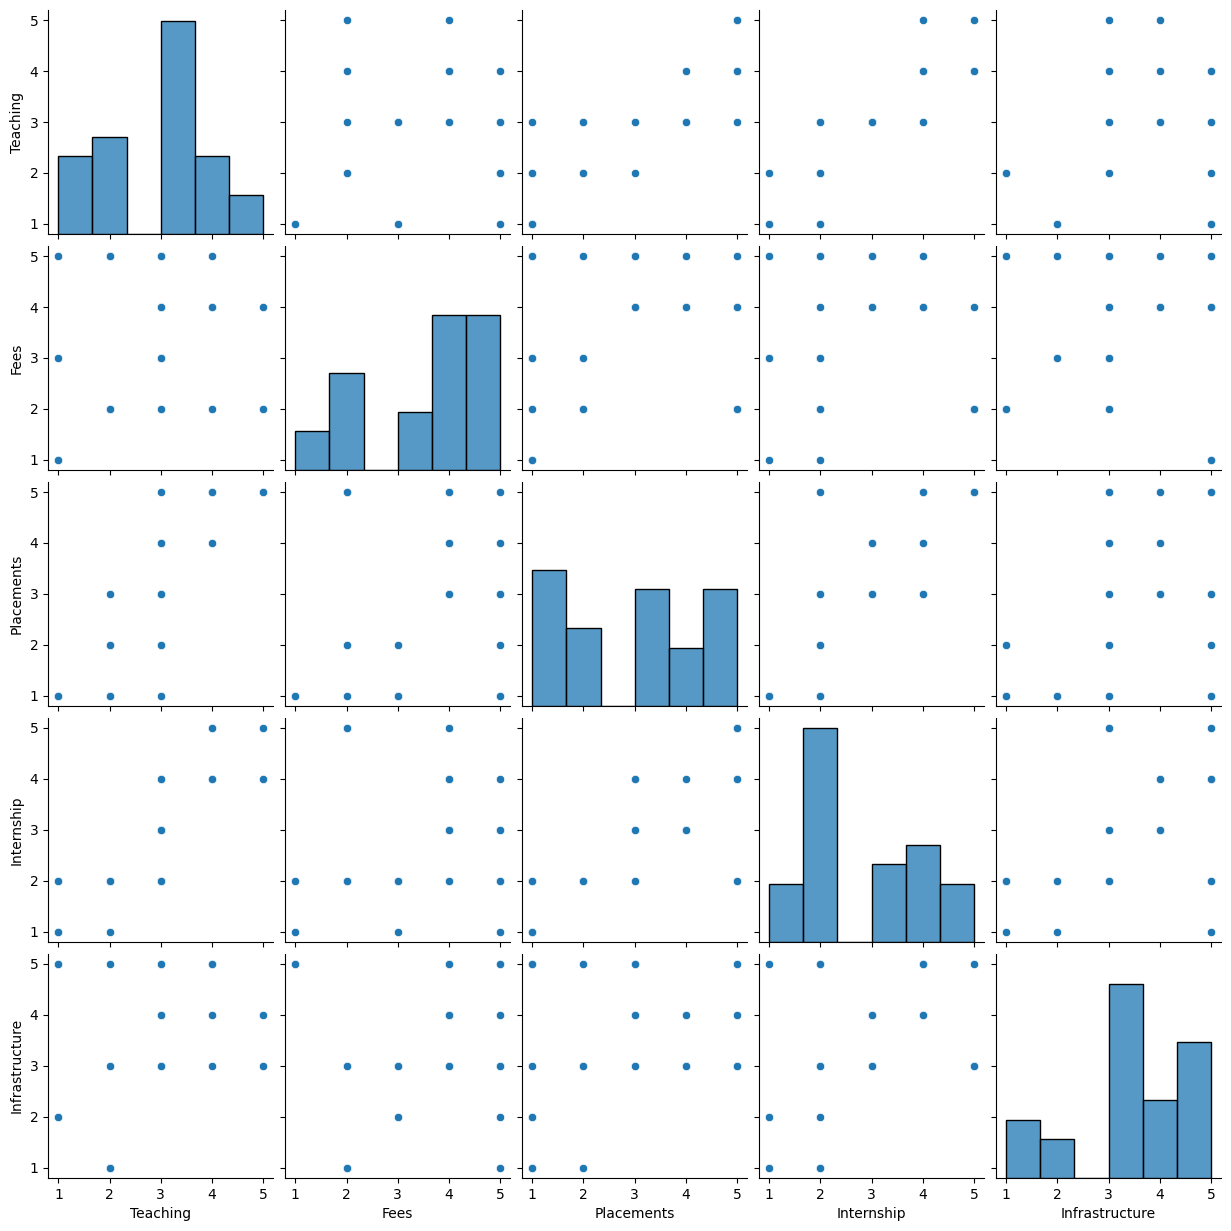

In [16]:
sns.pairplot(college_data[features]);

#### Comentarios
No veo ninguna posible agrupación, bueno con un poco de imaginación y forzando un poco, diría que hay un grupo de seis-cuatro puntos y otro de cuatro-tres, estos últimos a su vez pueden ser grupos más pequeños.

In [18]:
# Convertir 'SR_NO' en el índice de college_data
college_data_index = college_data.set_index(college_data['SR_NO'])

In [21]:
college_data_index = college_data_index.drop("SR_NO", axis=1)
print(college_data_index.columns)
print(college_data_index.head())

Index(['Engg_College', 'Teaching', 'Fees', 'Placements', 'Internship',
       'Infrastructure'],
      dtype='object')
      Engg_College  Teaching  Fees  Placements  Internship  Infrastructure
SR_NO                                                                     
1                A         5     2           5           5               3
2                B         4     2           5           5               3
3                C         4     5           5           4               5
4                D         5     4           5           4               4
5                E         2     5           2           2               5


### Ejercicio 5

Podríamos intentar cualquier tipo de clusterización, pero vamos a emplear una clusterización jerárquica porque sea cual sea la agrupación si que nos interesa establecer una jerarquía o una relación de distancia entre las diferentes instituciones (es algo que nos dicen desde el cliente, o sea "Negocio")

Elegido el tipo de clustering, tenemos que determinar los hiperparámetros. En este caso, el número de clusteres. Para ello nos vamos a apoyar en el dendrograma. Construye el dendrograma utilizando "average" como el método de ligado o linkage.



NOTA: no lo hemos hecho, ni dicho, pero nos quedaremos con todas las variables para que sean features y como están en la misma escala no hay que procesarlas otra vez.

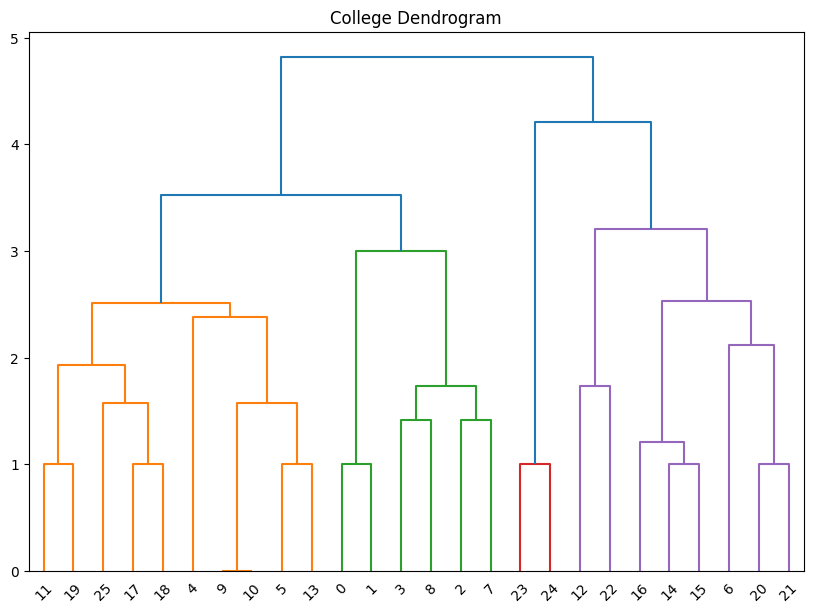

In [22]:
import scipy.cluster.hierarchy as shc
# import matplotlib.pyplot as plt (Está en la primeras importaciones)

plt.figure(figsize=(10, 7))
plt.title("College Dendrogram")

selected_data = college_data_index[features]
clusters = shc.linkage(selected_data, 
            method='average', 
            metric="euclidean")
shc.dendrogram(Z=clusters)
plt.show()

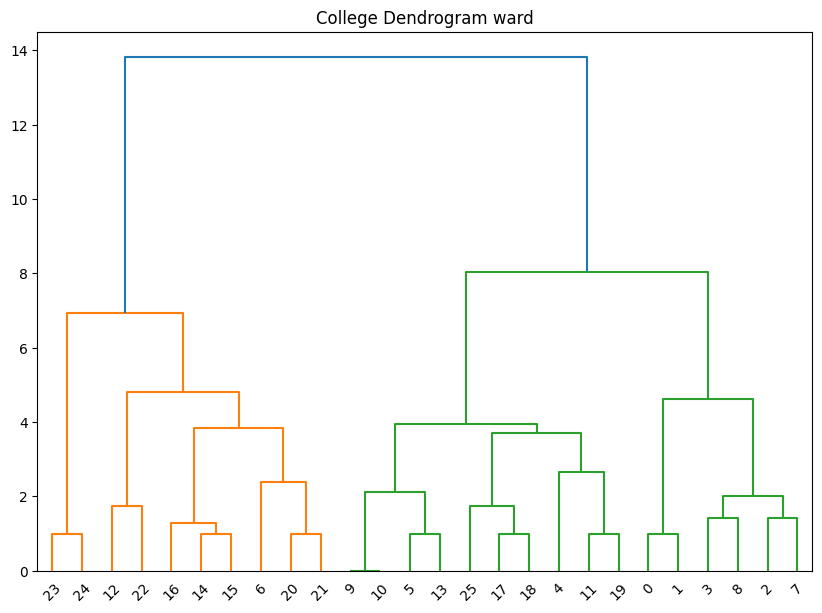

In [23]:
# Solo por curiosidad
plt.figure(figsize=(10, 7))
plt.title("College Dendrogram ward")

selected_data = college_data_index[features]
clusters = shc.linkage(selected_data, 
            method='ward', 
            metric="euclidean")
shc.dendrogram(Z=clusters)
plt.show()

### Ejercicio 6

Utilizando el método del máximo salto horizontal o método del máximo gap, ¿dónde colocarías la recta de corte? Vuelve a dibujar el dendrograma superponiendo esa línea. Decide el número de clusteres.

In [ ]:
plt.figure(figsize=(10, 7))
plt.title("College Dendrogram with line")
clusters = shc.linkage(selected_data, 
            method='average', 
            metric="euclidean")
shc.dendrogram(clusters)
plt.axhline(y = 3.3, color = 'r', linestyle = '-')
plt.show()

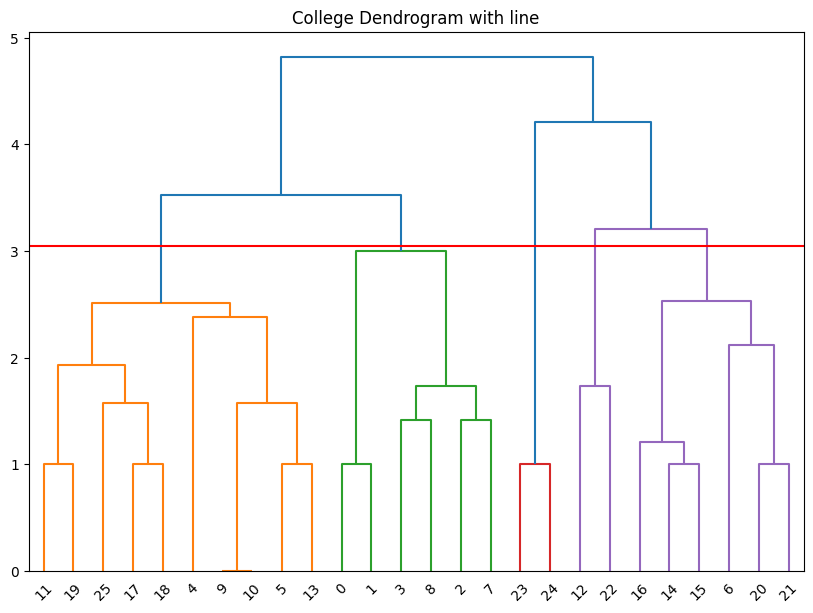

In [36]:
plt.figure(figsize=(10, 7))
plt.title("College Dendrogram with line")
clusters = shc.linkage(selected_data, 
            method='average', 
            metric="euclidean")
shc.dendrogram(clusters)
plt.axhline(y = 3.05, color = 'r', linestyle = '-')
plt.show()

### Ejercicio 7

Utilizando el codigo siguiente, emplea el número de clústeres obtenidos en el ejercicio anterior (usa 4 si no has logrado obtener un número que te convenza) y muestra cuántas instituciones hay por cluster. ¿Qué te llama la atención?

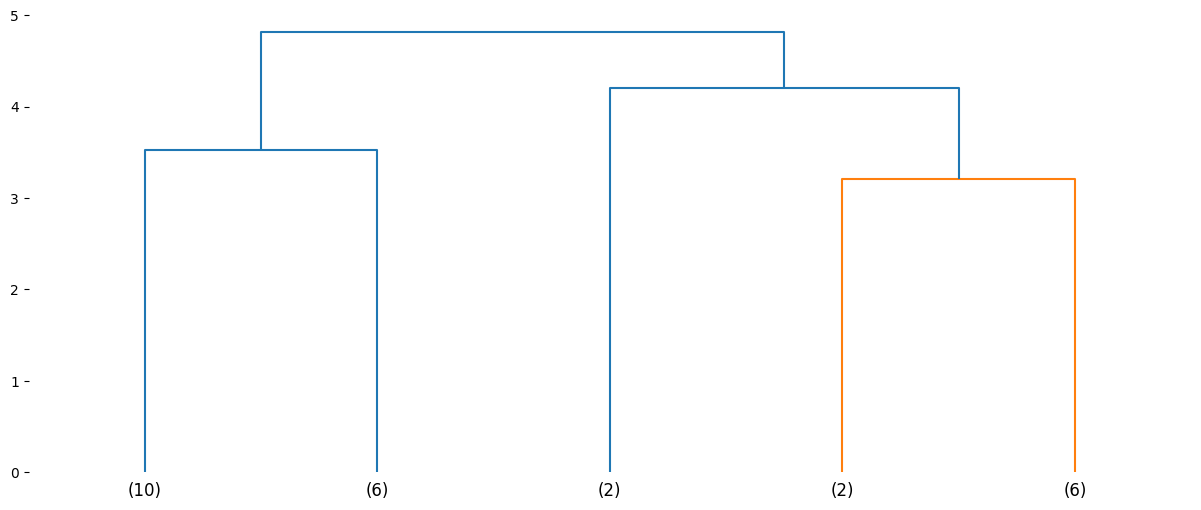

In [32]:
# Miramos cuantos elementos hay en cada cluster
plt.figure(figsize =(15,6))
dend = shc.dendrogram(Z=clusters,
                 truncate_mode='lastp',
                 p = 5, # SUSTITUYE AQUI
                 labels = None 
                 )
sns.despine(left=True, bottom=True)
plt.show()

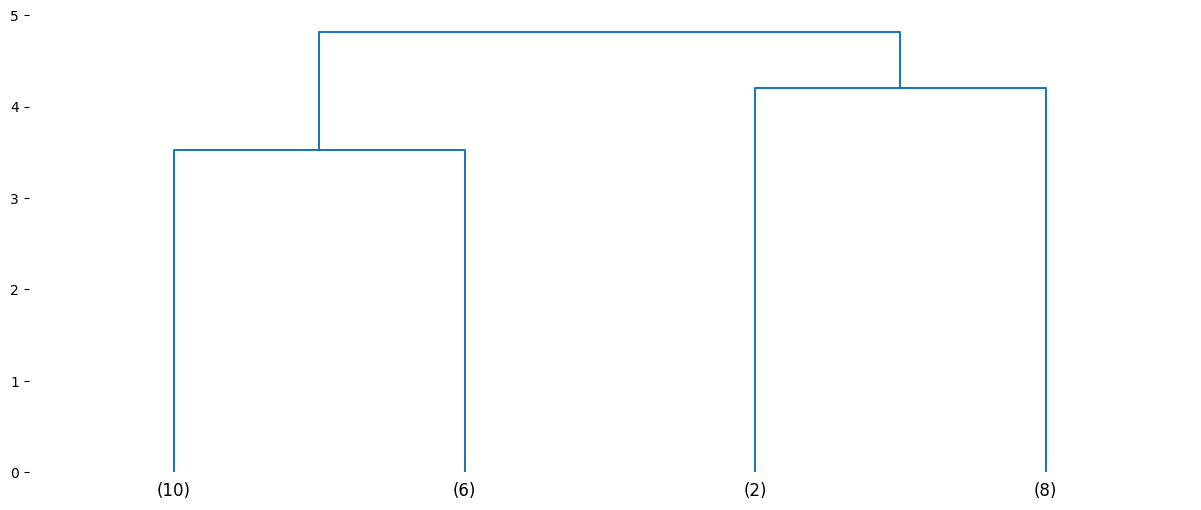

In [33]:
# Probamos con 4
plt.figure(figsize =(15,6))
dend = shc.dendrogram(Z=clusters,
                 truncate_mode='lastp',
                 p = 4, # SUSTITUYE AQUI
                 labels = None 
                 )
sns.despine(left=True, bottom=True)
plt.show()

**sns.despine()** es una función de Seaborn que elimina los bordes (spines) del gráfico para darle un aspecto más limpio y minimalista.  
sns.despine() --> elimina por defecto los de arriba y derecha.    
sns.despine(left=True, bottom=True) --> Esto elimina los 4 bordes, dejando el dendrograma sin ningún marco alrededor.

#### Cometarios:  
Después de ver los dos gráficos (5 clusters y 4 clusters), parece más coherente dividir en 4 clusters.

### Ejercicio 8

Previo a analizar las características específicas de cada clúster, analiza el clúster con menor número de elementos, es decir muestra las características de sus elementos constituyentes

In [37]:
from scipy.cluster.hierarchy import fcluster
etiquetas = fcluster(clusters, t=4, criterion='maxclust') # Obtenemos las etiquetas

college_data_index['cluster'] = etiquetas # Añadimos las estiquetas al dataframe

El parámetro **criterion** define cómo decides cortar el dendrograma para formar los clusters: 'maxclust'--> Fija el número de clusters que quieres. Número de clusters (ej: t=3).  
'distance'--> Corta donde la distancia de fusión supera un umbral. Valor de distancia (ej: t=10.5).  
Hay más opciones.  
Los clusters en fcluster se numeran desde 1, no desde 0.


In [41]:
print(college_data_index.groupby('cluster')[features].mean())

         Teaching   Fees  Placements  Internship  Infrastructure
cluster                                                         
1        2.800000  4.500    3.300000        2.80             3.8
2        4.333333  3.500    4.833333        4.50             4.0
3        1.000000  1.000    1.000000        1.50             5.0
4        2.125000  3.125    1.375000        1.75             2.0


In [43]:
print(college_data_index[college_data_index["cluster"]==3].describe())

       Teaching  Fees  Placements  Internship  Infrastructure  cluster
count       2.0   2.0         2.0    2.000000             2.0      2.0
mean        1.0   1.0         1.0    1.500000             5.0      3.0
std         0.0   0.0         0.0    0.707107             0.0      0.0
min         1.0   1.0         1.0    1.000000             5.0      3.0
25%         1.0   1.0         1.0    1.250000             5.0      3.0
50%         1.0   1.0         1.0    1.500000             5.0      3.0
75%         1.0   1.0         1.0    1.750000             5.0      3.0
max         1.0   1.0         1.0    2.000000             5.0      3.0


Lo más llamativo de este cluster es que tiene un patrón muy extremo y contradictorio:  
Infrastructure = 5 → Infraestructura excelente  
Teaching, Fees, Placements = 1 → Enseñanza, coste y colocación laboral muy bajos  

Básicamente son colegios con muy buenas instalaciones pero bajo rendimiento académico y laboral, lo cual los hace un grupo bastante peculiar dentro del análisis.
También destacar que el std=0 en la mayoría de variables indica que los dos elementos son casi idénticos entre sí, lo que hace que este cluster sea muy coherente internamente.

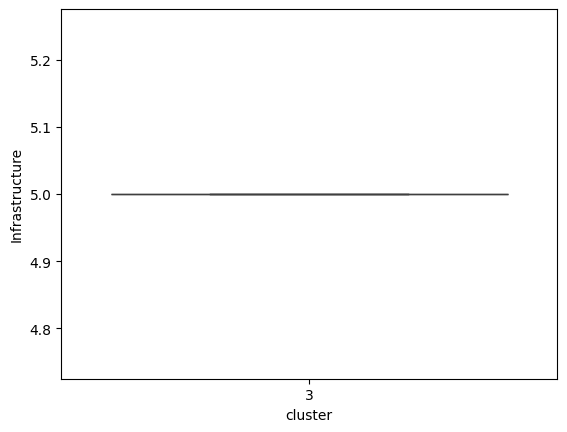

In [45]:
# Boxplot de una variable por cluster
sns.boxplot(x="cluster",
             y='Infrastructure', data=college_data_index[college_data_index["cluster"]==3]);
plt.show()

#### Comentario:  
La visualización de un solo cluster con dos instancias y una sola variable no nos da información.  
Probamos todos los cluster con una variable.  

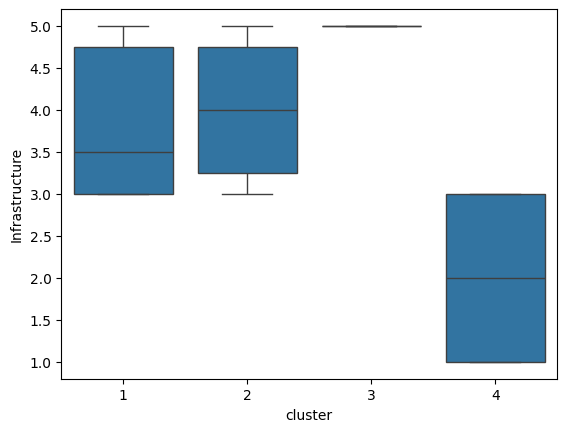

In [46]:
sns.boxplot(x='cluster', y='Infrastructure', data=college_data_index)
plt.show()

### Ejercicio 9

Nos hemos adelantado en el ejercicio anterior. Es hora de construir el clustering tal como hemos visto en el workout, utiliza el "AgglomerativeClustering" de sklearn para hacer el agrupamiento con el número de clusteres elegido y asigna las etiquetas a cada instancia. (Recuerda que hemos usado el linkage a "average", no a "ward" como se suele emplear)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

clustering_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='average')
clustering_model.fit(selected_data)
clustering_model.labels_


array([1, 1, 1, 1, 3, 3, 0, 1, 1, 3, 3, 3, 0, 3, 0, 0, 0, 3, 3, 3, 0, 0,
       0, 2, 2, 3])

In [49]:
clustering_model.n_clusters_

4

### Ejercicio 10

Comprueba que las instancias asignadas al clúster con 2 instancias son las entidades "X" e "Y"

In [50]:
college_data["etiquetas"]= clustering_model.labels_
college_data

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure,etiquetas
0,1,A,5,2,5,5,3,1
1,2,B,4,2,5,5,3,1
2,3,C,4,5,5,4,5,1
3,4,D,5,4,5,4,4,1
4,5,E,2,5,2,2,5,3
5,6,F,3,4,3,3,4,3
6,7,G,1,3,1,1,2,0
7,8,H,4,4,5,5,5,1
8,9,I,4,4,4,4,4,1
9,10,J,3,4,3,4,5,3


In [51]:
print(college_data[college_data['etiquetas'] == 2])

    SR_NO Engg_College  Teaching  Fees  Placements  Internship  \
23     24            X         1     1           1           2   
24     25            Y         1     1           1           1   

    Infrastructure  etiquetas  
23               5          2  
24               5          2  


### Ejercicio 11

Igual que podemos intuir que el cluster "pequeño" es el de las instituiciones peor puntuadas, muestra los valores medios de las features para cada clúster y da tu interpretación de que es cada uno. Emplea un gráfico comparativo.


In [57]:
for valor in sorted(college_data["etiquetas"].unique()):
 print(f"Cluster {valor}: \n")
 print(college_data[college_data["etiquetas"]==valor][features].describe())

Cluster 0: 

       Teaching      Fees  Placements  Internship  Infrastructure
count  8.000000  8.000000    8.000000     8.00000         8.00000
mean   2.125000  3.125000    1.375000     1.75000         2.00000
std    0.834523  1.246423    0.517549     0.46291         0.92582
min    1.000000  2.000000    1.000000     1.00000         1.00000
25%    1.750000  2.000000    1.000000     1.75000         1.00000
50%    2.000000  3.000000    1.000000     2.00000         2.00000
75%    3.000000  3.500000    2.000000     2.00000         3.00000
max    3.000000  5.000000    2.000000     2.00000         3.00000
Cluster 1: 

       Teaching      Fees  Placements  Internship  Infrastructure
count  6.000000  6.000000    6.000000    6.000000        6.000000
mean   4.333333  3.500000    4.833333    4.500000        4.000000
std    0.516398  1.224745    0.408248    0.547723        0.894427
min    4.000000  2.000000    4.000000    4.000000        3.000000
25%    4.000000  2.500000    5.000000    4.000000 

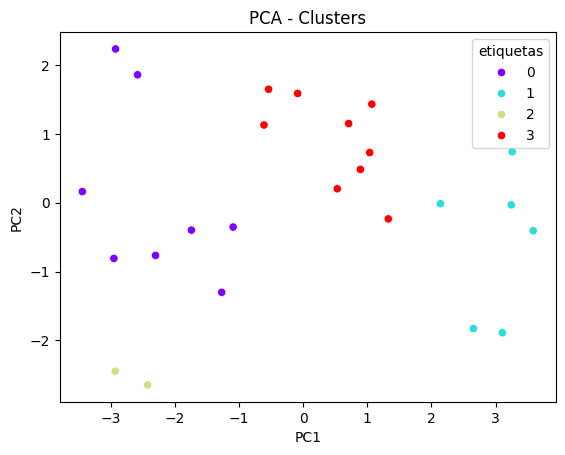

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
componentes = pca.fit_transform(college_data[features])

college_data['PC1'] = componentes[:, 0]
college_data['PC2'] = componentes[:, 1]

sns.scatterplot(x='PC1', y='PC2', hue='etiquetas', data=college_data, palette= "rainbow")
plt.title('PCA - Clusters')
plt.show()

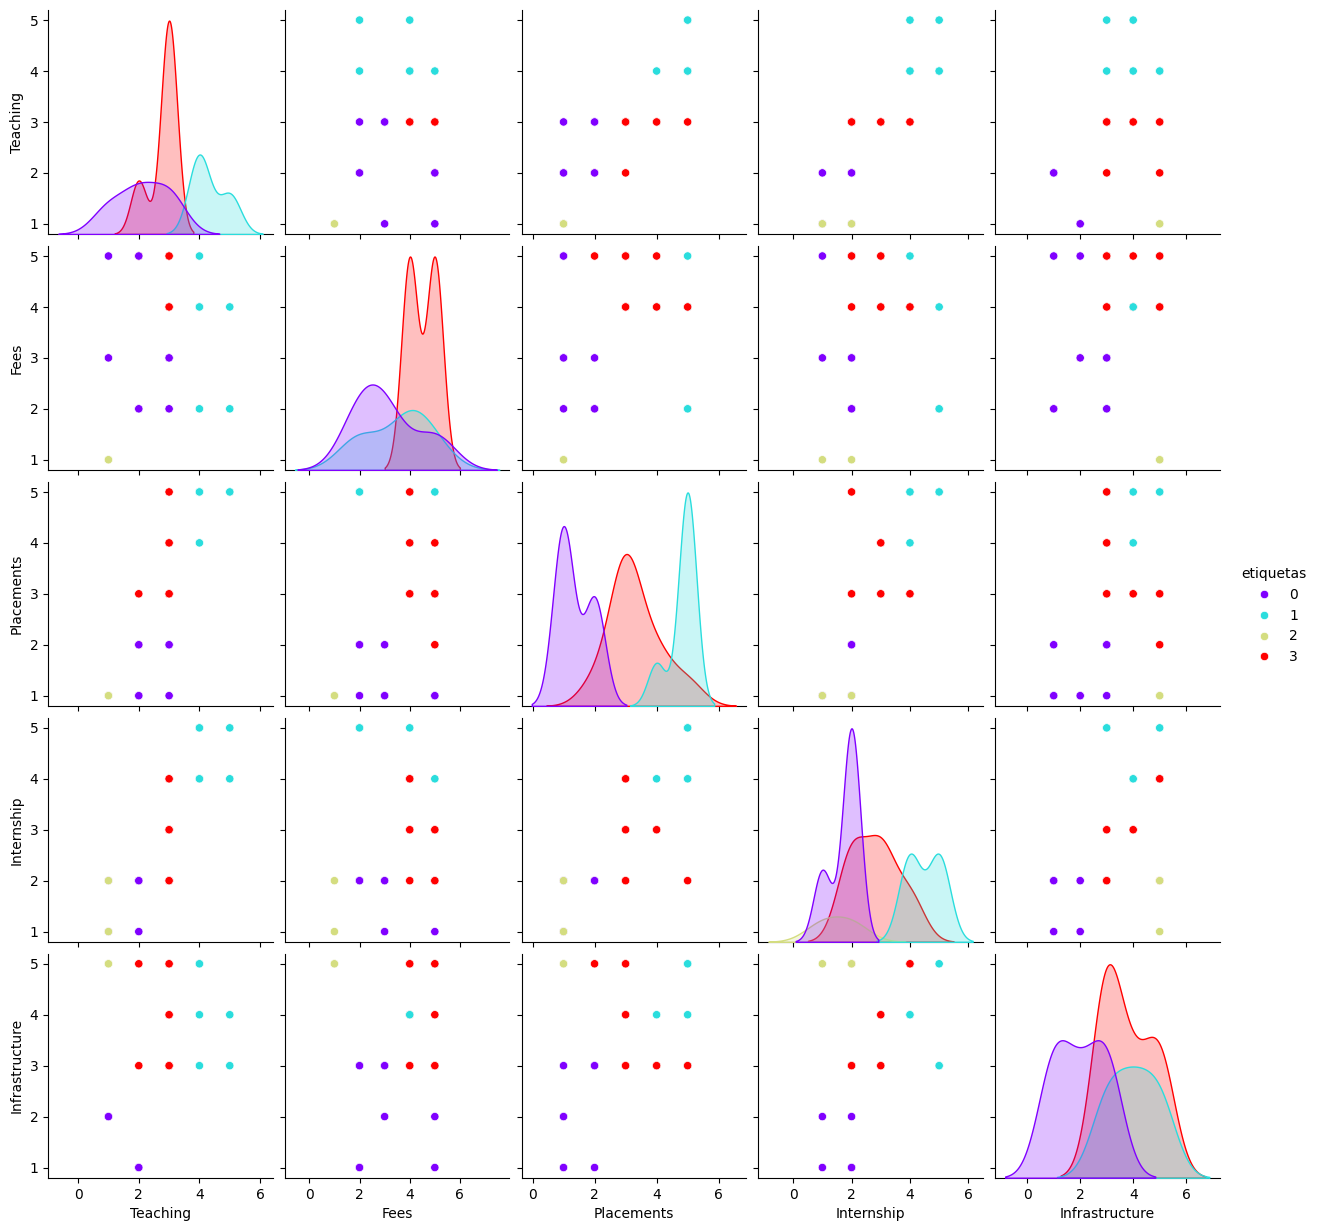

In [61]:
sns.pairplot(college_data[features + ['etiquetas']], 
             hue='etiquetas', palette="rainbow")
plt.show()

Cluster 0 — El caro y mediocre: Teaching y Placements bajos (1-2), Fees medio-altas (3-4), Infrastructure mediocre (2-3) ---> Mala relación calidad-precio.  
Cluster 1 — El equilibrado y eficiente: Teaching y Placements medios-altos (3-4),Fees moderadas (2-3), Infrastructure buena (3-4) ---> Mejor relación calidad-precio del conjunto.  
Cluster 2 - El peculiar: Teaching, Fees y Placements muy bajos (1), Infrastructure excelente (5) --->
Solo 2 elementos, muy atípico.  
Cluster 3 - El premium: Teaching y Placements altos (3-5), Fees altas (4-5), Infrastructure alta (4-5) ---> Alta calidad pero también alto coste.

### Ejercicio 12

Para finalizar, ¿qué recomendaciones darías a diferentes clientes en base a los patrones encontrados?

Recomendación general para la institución:  
Los colegios del Cluster 0 deberían revisar su política de precios, ya que cobran demasiado en relación a lo que ofrecen.  
Los colegios del Cluster 2 tienen un problema claro: invierten en infraestructura pero descuidan completamente la calidad académica.  
El Cluster 1 es el modelo a seguir en términos de equilibrio calidad-precio.  


Recomendación para estudiantes:  
Cluster 1, ofrece buena enseñanza y prácticas a un precio razonable.
Cluster 3, el más completo en todas las variables, altas Fees pero justificadas por Teaching, Placements e Infrastructure excelentes.  
Cluster 0 y 2 no paecen recomendables.


